## 1. Importing Data

In [1]:
import numpy as np
import h5py #h5py is a package for interface with HDF5 data files

In [2]:
# Import Test Data File
TestFile =  h5py.File('Sean_CG100_ST10us_600V_electrons_2DScan_100um_1sAq_0248.hdf5','r')

# A hdf5 file is structured like a Python dictionary; the keys tell us what is stored in the file
list(TestFile.keys())

['adc_counts_0', 'adc_counts_3', 'metadata', 'pha_3', 'trigger_timings']

In [3]:
#The metadata is stored as attributes within the hdf5 file: here are the names and values of each one
for attr_name in TestFile['/metadata'].attrs: print(attr_name, TestFile['/metadata'].attrs[attr_name])

active_channels [0 3]
channel_a_PHAToggled False
channel_a_active True
channel_a_channel_id 0
channel_a_coupling 1
channel_a_live_view True
channel_a_name a
channel_a_offset 100
channel_a_pha_active False
channel_a_range 2
channel_a_verified True
channel_a_waveformsToggled True
channel_b_PHAToggled False
channel_b_active False
channel_b_channel_id 1
channel_b_coupling 1
channel_b_live_view False
channel_b_name b
channel_b_offset 0.0
channel_b_pha_active False
channel_b_range 0
channel_b_verified True
channel_b_waveformsToggled False
channel_c_PHAToggled False
channel_c_active False
channel_c_channel_id 2
channel_c_coupling 1
channel_c_live_view False
channel_c_name c
channel_c_offset 0.0
channel_c_pha_active False
channel_c_range 0
channel_c_verified True
channel_c_waveformsToggled False
channel_d_PHAToggled True
channel_d_active True
channel_d_channel_id 3
channel_d_coupling 1
channel_d_live_view True
channel_d_name d
channel_d_offset -50
channel_d_pha_active True
channel_d_range 4
ch

In [4]:
#The other three groups in the hdf5 file contain: data from the preamp, the shaping amp, and the time intervals between which each trigger was recorded
PreAmpPulses     = np.array(TestFile['adc_counts_0'])
ShapingAmpPulses = np.array(TestFile['adc_counts_3'])
TriggerTimings   = np.array(TestFile['trigger_timings'])

In [5]:
#The time range for each pulse can be calculated from the timebase property of the metadata
Timebase = TestFile['/metadata'].attrs['timebase']
if Timebase > 4: t = (Timebase-3)*16
else:            t = (2**Timebase)

N_Datapoints = len(PreAmpPulses[0]) 
Time_us = np.arange(0, t*N_Datapoints, t)/1e3

In [6]:
#The length of the preamp data array gives the number of triggers recorded for the dataset
N_Captures = len(PreAmpPulses)
print(N_Captures)
print(len(ShapingAmpPulses))

956
956


In [7]:
#The preamp and shaping amp data can be converted from adc to mV using the range property of the metadata
ChARange = TestFile['/metadata'].attrs['channel_a_range']
ChDRange = TestFile['/metadata'].attrs['channel_d_range']

#pulse = pulse*range/32767

In [8]:
# Add this after cell 7 — convert both channels to mV
PreAmpPulses_mV      = PreAmpPulses      * ChARange / 32767
ShapingAmpPulses_mV  = ShapingAmpPulses  * ChDRange / 32767

## 2. Initial Data Visualisation

In [9]:
import matplotlib.pyplot as plt

In [10]:
#Define number of example pulses to plot
N_ExamplePulses = 4
ExamplePulseIndices = np.linspace(0, N_Captures - 1, N_ExamplePulses, dtype=int)

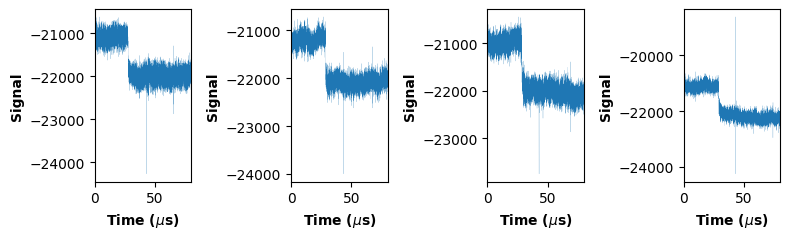

In [11]:

fig, axes = plt.subplots(1,4, figsize=(8,2.5), tight_layout=True)
for i in range(len(axes)):
    axes[i].set_xlabel(r"Time ($\mu$s)", fontweight="bold")
    axes[i].set_ylabel("Signal", fontweight="bold")
    axes[i].set_xlim(0, Time_us[-1])
    axes[i].plot(Time_us, PreAmpPulses[ExamplePulseIndices[i]], linewidth=0.1)
plt.show()

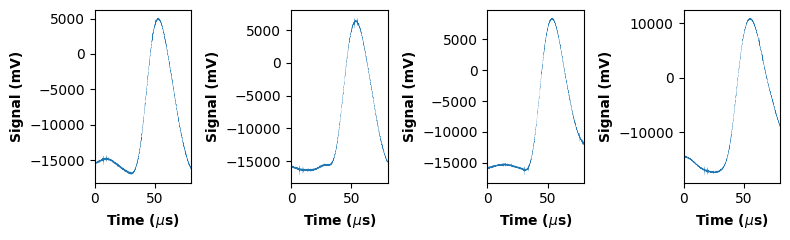

In [12]:
fig, axes = plt.subplots(1,4, figsize=(8,2.5), tight_layout=True)
for i in range(len(axes)):
    axes[i].set_xlabel(r"Time ($\mu$s)", fontweight="bold")
    axes[i].set_ylabel("Signal (mV)", fontweight="bold")
    axes[i].set_xlim(0, Time_us[-1])
    axes[i].plot(Time_us, ShapingAmpPulses[ExamplePulseIndices[i]], linewidth=0.1)
plt.show()

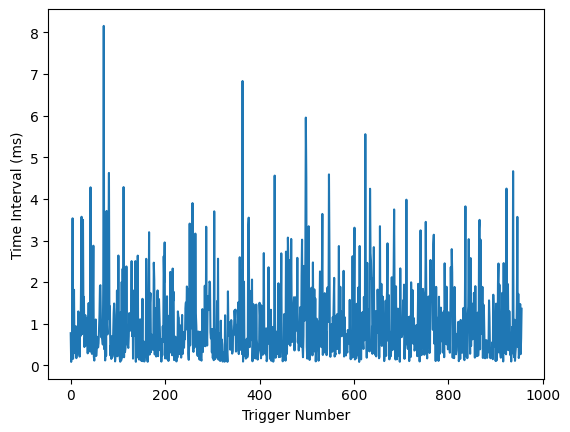

In [13]:
#Plot trigger timings to check for a trend of slowing pulse detection
plt.plot(TriggerTimings*1000)
plt.xlabel("Trigger Number")
plt.ylabel("Time Interval (ms)")
plt.show()

## 3. Shaping Amplifier Processing

## 4. Initial Preamp Pulse Processing

In [14]:
import sys
sys.path.append(r'C:\Users\smc241\OneDrive - University of Cambridge\StranksLab-CEB-107-112-WDO-2\Experiments\diamond\Beamtime Dec 2025\Pulse data')

from Functions import DataSmoothing

In [15]:
#If value is known for which detector is saturated, saturated pulses can be removed from the dataset here
#Plotting the rejected pulses is optional

#AcceptedPulses, SaturatedPulseCounter = SaturationCheck(PreAmpPulses, PlotRejects=False, SaturationLevel)

In [16]:
"""
# Convert preamp pulses to mV first
PreAmpPulses_mV = PreAmpPulses * ChARange / 32767

# Then background correct the mV data
CorrectedPulses = DataSmoothing.BackgroundCorrection(PreAmpPulses_mV, N_BGPoints=2000)
"""

'\n# Convert preamp pulses to mV first\nPreAmpPulses_mV = PreAmpPulses * ChARange / 32767\n\n# Then background correct the mV data\nCorrectedPulses = DataSmoothing.BackgroundCorrection(PreAmpPulses_mV, N_BGPoints=2000)\n'

In [17]:
#Carry out background correction by subtracting average of first N data points; make pulses positive
CorrectedPulses = DataSmoothing.BackgroundCorrection(PreAmpPulses, N_BGPoints = 2000)

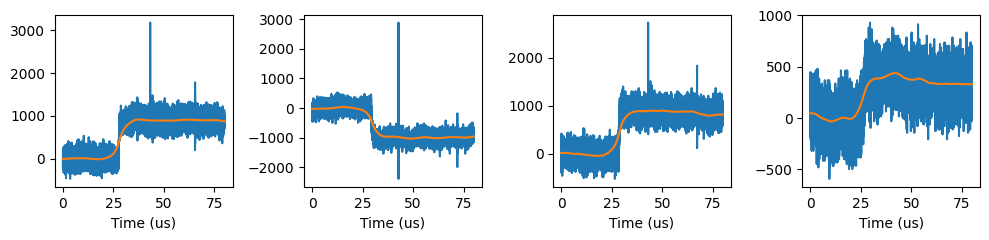

In [18]:
#Initial Smoothing is carried out using Whittaker-Eilers Smoother
#https://github.com/mhvwerts/whittaker-eilers-smoother/blob/master/whittaker_smooth.py
#Experiment with the parameters until the pulse is over-smoothed
SmoothedPulses = DataSmoothing.WhittakerSmooth(CorrectedPulses, lmbd=1e5, order=1)

fig, axes = plt.subplots(1,4, figsize=(10,2.5), tight_layout=True)
for i in range(4):
    axes[i].plot(Time_us, CorrectedPulses[i])
    axes[i].plot(Time_us, SmoothedPulses[i])
    axes[i].set_xlabel("Time (us)")
plt.show()

## 5. Pulse Identification

In [19]:
from Functions import PulseID_27032026
from Functions import PulseCharacterisation

In [20]:
#Peak Prominence and Peak Height Parameters must be tuned:
#Too high and actual peaks are excluded as noise (adding to bad trigger count)
#Too low and noise is included as peaks (adding to pileup counter)
#Set Plots to True to see what is being rejected

AcceptedPulseList, SmoothedDerivativeList, PeakIndexList, AcceptedIndices = PulseID_27032026.PeakAcceptance(CorrectedPulses, SmoothedPulses, PkProminence=0.1, PkHeight=0.2, Plots=False)

Data Sets with no Pulse: 0
Pulses Rejected for Pileup: 42
Pulses Rejected for Baseline Instability: 0
Accepted Pulses: 914


In [21]:
# Option to re-smooth pulse at this stage 
# below I have just used the raw pulse again
# You don't want to put an overly smoothed pulse into the pulse characterisation functions as it will lengthen the rise time
# But for very noisy pulses you might find it hard to accurately pull out where the pulse crosses the 10 and 90 thresholds without some smoothign

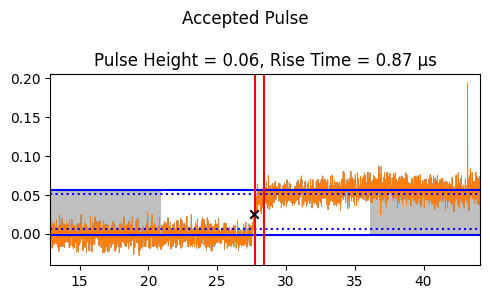

Number of Pulses Provided: 914
Number of Rejected Pulses: 65
Number of Usable Pulses: 849


In [22]:
AcceptedPulseList_mV = [pulse * ChARange / 32767 for pulse in AcceptedPulseList]
SmoothedDerivativeList_mV = [d * ChARange / 32767 for d in SmoothedDerivativeList]

PulseHeights, RiseTimes, RejectedPulseCounter, PulseHeightErrors, CharacterisedIndices = \
    PulseCharacterisation.AlphaPulsePeakCharacterisation(
        AcceptedPulseList_mV,
        AcceptedPulseList_mV,
        SmoothedDerivativeList_mV,
        PeakIndexList,
        Time_us,
        BoundaryWindow=10,
        BoundaryThreshold=0.1 * ChARange / 32767,
        OutsideROI=1000,
        PlotNumber=1)

# Map characterised indices back to original trigger indices
PreampAcceptedTriggers = np.array(AcceptedIndices)[CharacterisedIndices - 1]

In [23]:
"""
# Build shaping amp accepted trigger indices (those that passed height threshold)
ShapingAcceptedTriggers = []
all_pulse_heights_indexed = []

for i, single_peak in enumerate(PeakIndex):
    ph, peak_start_idx, base, top = Shaping_amp.find_pulse_height(
        raw_data=np.array(ShapingAmpPulses_mV[i]).flatten(),
        smoothed_data=np.array(SmoothedShapingPulses_mV[i]).flatten(),
        peak_index=int(single_peak),
        n_sigma=3,
        min_baseline_samples=200,
        baseline_window=200,
    )
    if ph is not None and not np.isnan(ph) and abs(ph) >= 0.1:
        ShapingAcceptedTriggers.append(i)
        all_pulse_heights_indexed.append(ph)

ShapingAcceptedTriggers = np.array(ShapingAcceptedTriggers)

# Find triggers accepted by BOTH pipelines
CommonTriggers = np.intersect1d(PreampAcceptedTriggers, ShapingAcceptedTriggers)
print(f"Preamp accepted:  {len(PreampAcceptedTriggers)}")
print(f"Shaping accepted: {len(ShapingAcceptedTriggers)}")
print(f"Common triggers:  {len(CommonTriggers)}")

# Filter both datasets to common triggers only
preamp_mask  = np.isin(PreampAcceptedTriggers, CommonTriggers)
shaping_mask = np.isin(ShapingAcceptedTriggers, CommonTriggers)

PulseHeights_matched      = PulseHeights[preamp_mask]
RiseTimes_matched         = RiseTimes[preamp_mask]
all_pulse_heights_matched = np.array(all_pulse_heights_indexed)[shaping_mask]
"""

'\n# Build shaping amp accepted trigger indices (those that passed height threshold)\nShapingAcceptedTriggers = []\nall_pulse_heights_indexed = []\n\nfor i, single_peak in enumerate(PeakIndex):\n    ph, peak_start_idx, base, top = Shaping_amp.find_pulse_height(\n        raw_data=np.array(ShapingAmpPulses_mV[i]).flatten(),\n        smoothed_data=np.array(SmoothedShapingPulses_mV[i]).flatten(),\n        peak_index=int(single_peak),\n        n_sigma=3,\n        min_baseline_samples=200,\n        baseline_window=200,\n    )\n    if ph is not None and not np.isnan(ph) and abs(ph) >= 0.1:\n        ShapingAcceptedTriggers.append(i)\n        all_pulse_heights_indexed.append(ph)\n\nShapingAcceptedTriggers = np.array(ShapingAcceptedTriggers)\n\n# Find triggers accepted by BOTH pipelines\nCommonTriggers = np.intersect1d(PreampAcceptedTriggers, ShapingAcceptedTriggers)\nprint(f"Preamp accepted:  {len(PreampAcceptedTriggers)}")\nprint(f"Shaping accepted: {len(ShapingAcceptedTriggers)}")\nprint(f"Co

In [24]:
def AlphaPlots(PulseHeights, RiseTimes, Time_microsec, SampleName, nBinsPH, nBinsRT):
    # Plot histogram for pulse heights
    fig, ax = plt.subplots(1,1, figsize=(2.5,2.5), tight_layout=True)
    ax.hist(PulseHeights, np.linspace(0,max(PulseHeights)*1.1, num=nBinsPH))
    ax.set_xlabel("Pulse Height", fontsize=8, fontweight="bold")
    ax.set_ylabel("Frequency", fontsize=8, fontweight="bold")
    ax.tick_params(axis='both', labelsize=8)
    plt.savefig(str(SampleName)+'PulseHeights')
    
    AvRiseTime = np.median(RiseTimes)
    fig, ax = plt.subplots(1,1, figsize=(2.5,2.5), tight_layout=True)
    ax.hist(RiseTimes, np.linspace(0,max(RiseTimes)*1.1, num=nBinsRT))
    ax.set_xlabel(r"Rise Time ($\mu$s)", fontsize=8, fontweight="bold")
    ax.set_ylabel("Frequency", fontsize=8, fontweight="bold")
    ax.tick_params(axis='both', labelsize=8)
    ax.text(0.8, 0.8, "{:.2f}".format(AvRiseTime)+r"$ \mu$s", ha="center", transform=ax.transAxes, fontsize=8)
    plt.savefig(str(SampleName)+'RiseTimes')
    plt.show()
    
    plt.hist2d(RiseTimes, PulseHeights, bins=(nBinsRT, nBinsPH), cmap='Oranges')
    plt.colorbar(label='Frequency')
    plt.xlabel('RiseTime', fontweight="bold")
    plt.ylabel('PulseHeight', fontweight="bold")
    plt.title(str(SampleName)+' Pulses', fontweight="bold")
    plt.show()

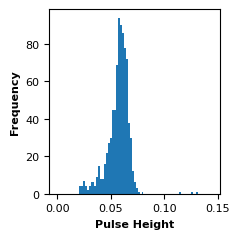

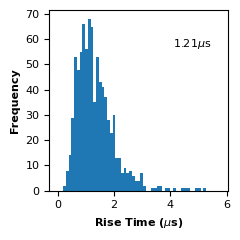

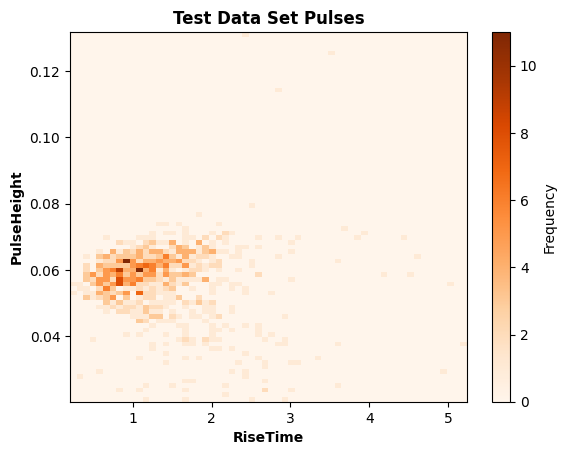

In [25]:
AlphaPlots(PulseHeights, RiseTimes, Time_us, "Test Data Set", nBinsPH=80, nBinsRT=60)

In [31]:
# ── Define your pulse height range ───────────────────────────────────────────
PH_MIN = 0.05   # mV  <-- set your lower bound
PH_MAX = 0.07   # mV  <-- set your upper bound

# PulseHeights and RiseTimes are already computed by AlphaPulsePeakCharacterisation
# CharacterisedIndices maps back to AcceptedPulseList_mV
in_range_mask = (PulseHeights >= PH_MIN) & (PulseHeights <= PH_MAX)
in_range_pulse_indices = np.where(in_range_mask)[0]   # indices into PulseHeights / AcceptedPulseList_mV

print(f"Pulses in range [{PH_MIN}, {PH_MAX}] mV: {len(in_range_pulse_indices)}")
print(f"  (out of {len(PulseHeights)} total characterised pulses)")

Pulses in range [0.05, 0.07] mV: 671
  (out of 849 total characterised pulses)


  Pulse     0 | height = 0.0575 mV | rise time = 0.8700 µs
  Pulse    50 | height = 0.0653 mV | rise time = 1.4200 µs
  Pulse   108 | height = 0.0573 mV | rise time = 0.7100 µs
  Pulse   167 | height = 0.0625 mV | rise time = 0.9300 µs
  Pulse   220 | height = 0.0546 mV | rise time = 0.6400 µs
  Pulse   279 | height = 0.0512 mV | rise time = 0.7500 µs
  Pulse   337 | height = 0.0656 mV | rise time = 1.2800 µs
  Pulse   393 | height = 0.0622 mV | rise time = 1.4700 µs
  Pulse   449 | height = 0.0567 mV | rise time = 1.3000 µs
  Pulse   506 | height = 0.0625 mV | rise time = 1.1500 µs
  Pulse   564 | height = 0.0664 mV | rise time = 1.1600 µs
  Pulse   619 | height = 0.0552 mV | rise time = 1.4300 µs
  Pulse   680 | height = 0.0674 mV | rise time = 1.1100 µs
  Pulse   735 | height = 0.0556 mV | rise time = 1.7000 µs
  Pulse   790 | height = 0.0620 mV | rise time = 1.7800 µs
  Pulse   848 | height = 0.0633 mV | rise time = 1.3300 µs


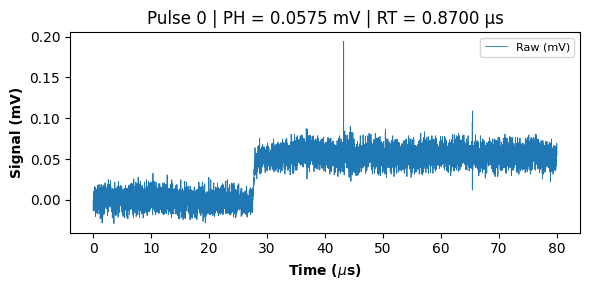

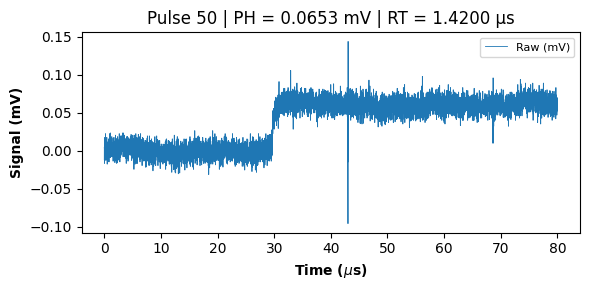

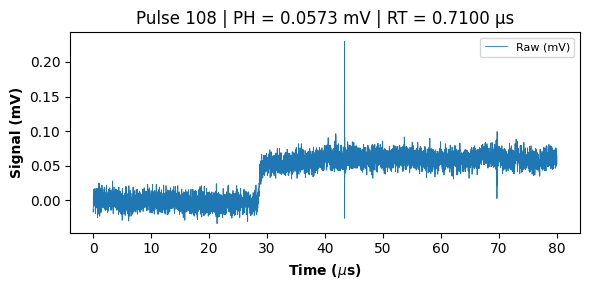

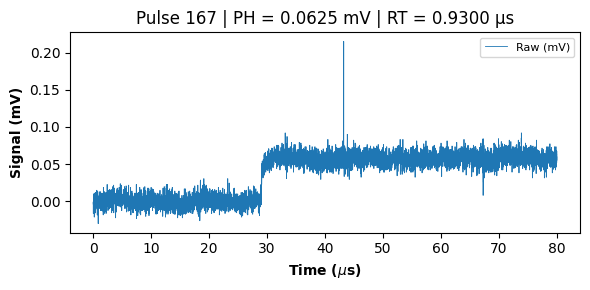

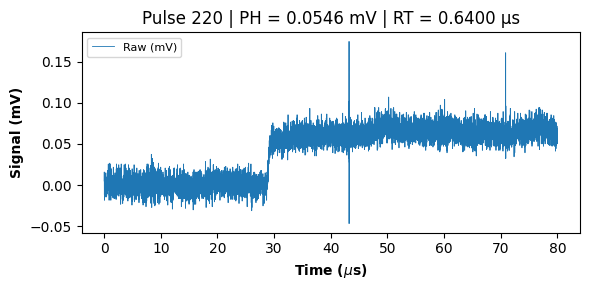

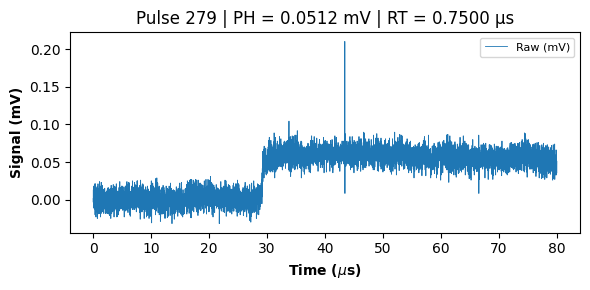

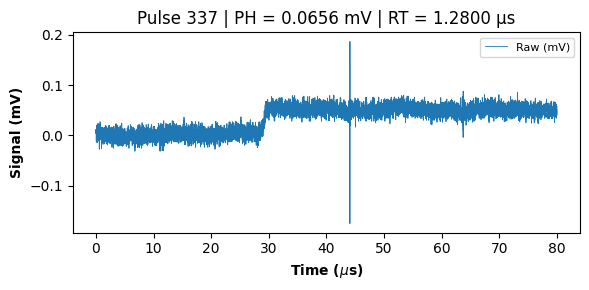

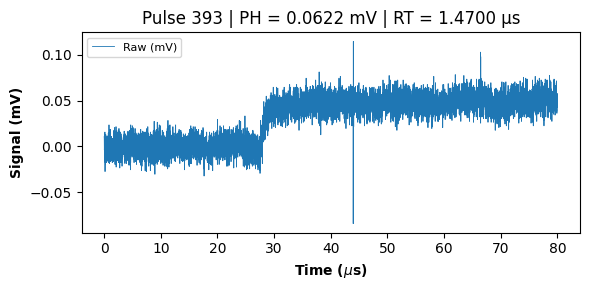

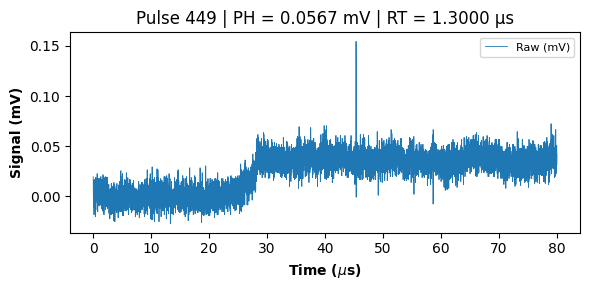

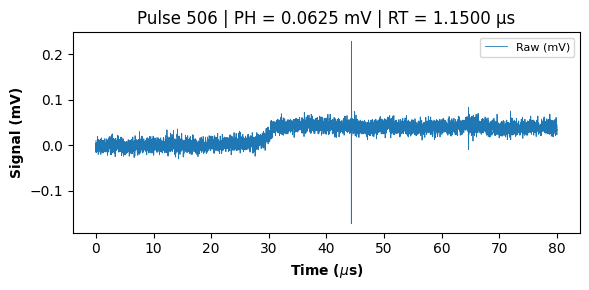

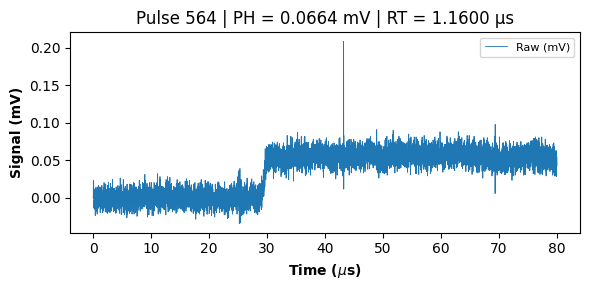

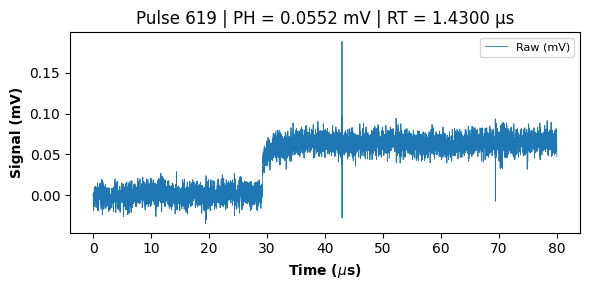

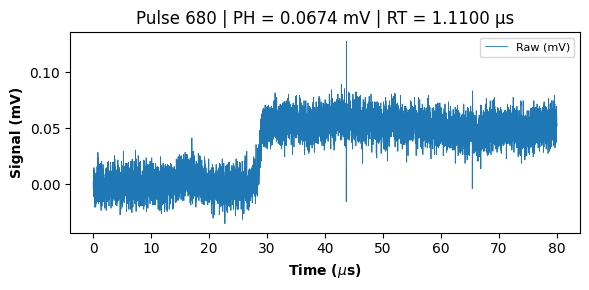

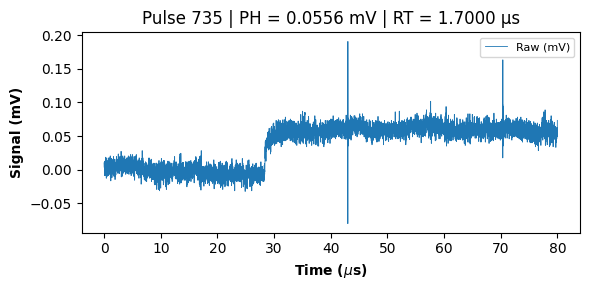

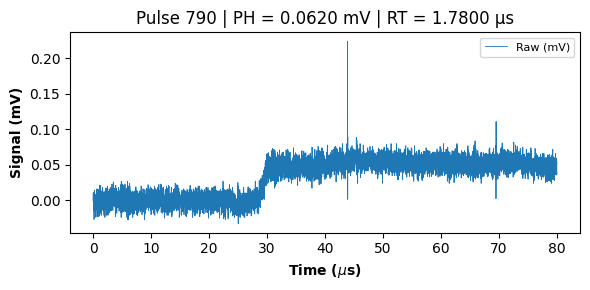

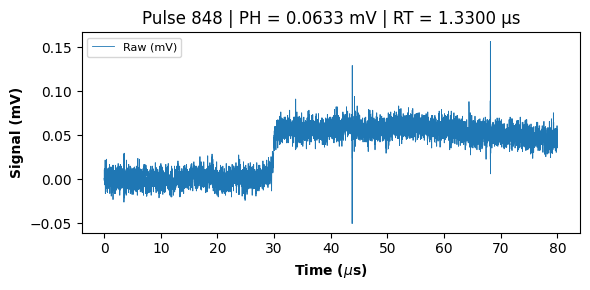

In [32]:
# ── Plot accepted pulses within the defined height range ─────────────────────
N_PLOTS = 16   # <-- how many to plot (evenly spaced across matched set)

if len(in_range_pulse_indices) == 0:
    print("No pulses found in the specified range. Try adjusting PH_MIN / PH_MAX.")
else:
    # manual indices
    # sample_indices = [0, 10, 25, 50]
    
    # evenly spaced indices
    sample_indices = np.linspace(0, len(in_range_pulse_indices) - 1,
                                 min(N_PLOTS, len(in_range_pulse_indices)), dtype=int)

    for si in sample_indices:
        pulse_idx = in_range_pulse_indices[si]
        ph  = PulseHeights[pulse_idx]
        rt  = RiseTimes[pulse_idx]
        raw = np.array(AcceptedPulseList_mV[pulse_idx]).flatten()

        print(f"  Pulse {pulse_idx:>5d} | height = {ph:.4f} mV | rise time = {rt:.4f} µs")

        fig, ax = plt.subplots(figsize=(6, 3), tight_layout=True)
        ax.plot(Time_us, raw, linewidth=0.6, label="Raw (mV)")
        ax.set_xlabel(r"Time ($\mu$s)", fontweight="bold")
        ax.set_ylabel("Signal (mV)", fontweight="bold")
        ax.set_title(f"Pulse {pulse_idx} | PH = {ph:.4f} mV | RT = {rt:.4f} µs")
        ax.legend(fontsize=8)
        #plt.show()


Saved: Sean_CG100_ST10us_600V_electrons_2DScan_100um_1sAq_0248_PH_0.05_to_0.07_pulse_grid.png


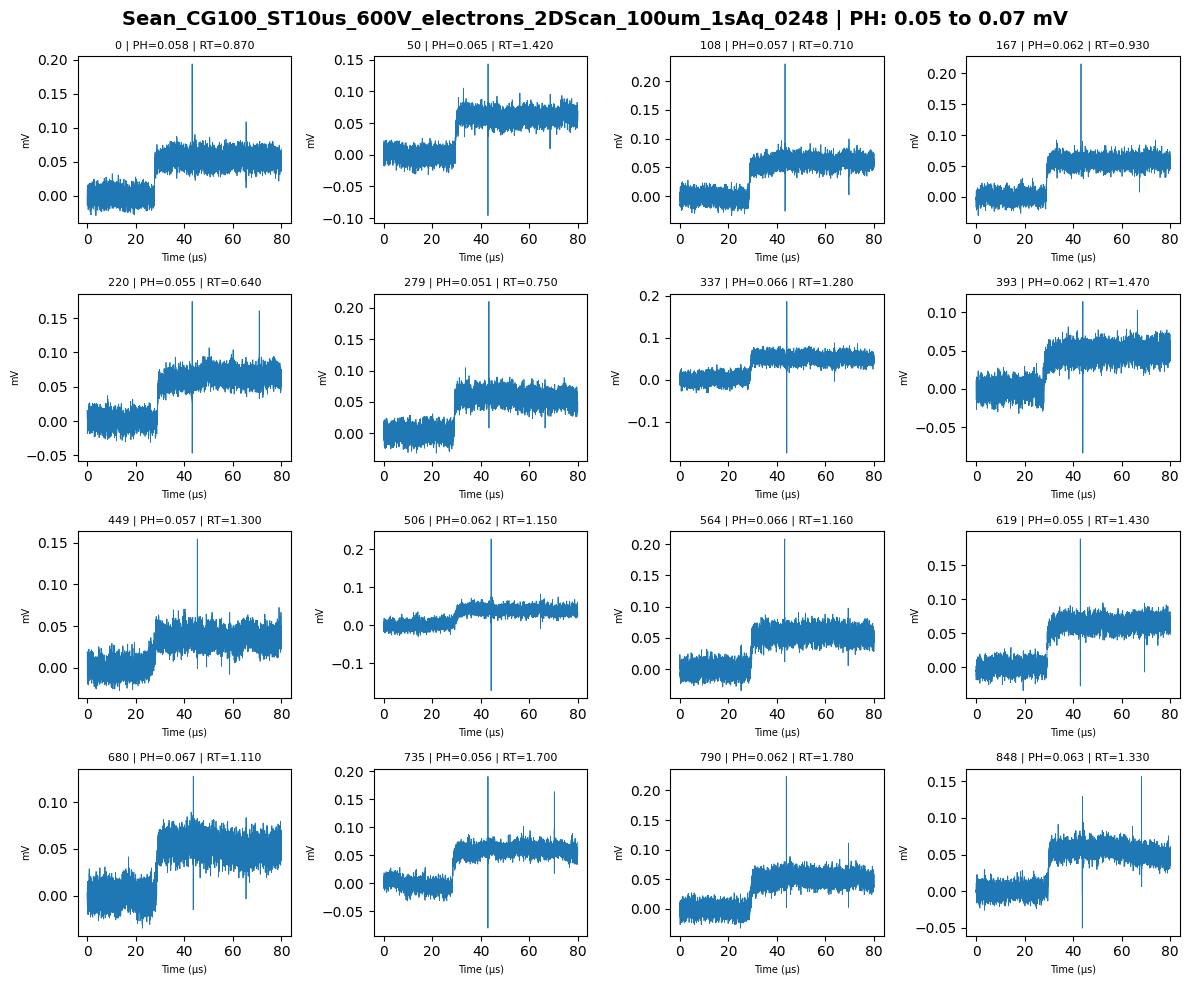

In [33]:
# ── 4x4 grid of accepted pulses + save as PNG ────────────────────────────────
import os

N_ROWS, N_COLS = 4, 4
N_PLOTS = N_ROWS * N_COLS

if len(in_range_pulse_indices) == 0:
    print("No pulses found in the specified range. Try adjusting PH_MIN / PH_MAX.")
else:
    sample_indices = np.linspace(
        0, len(in_range_pulse_indices) - 1,
        min(N_PLOTS, len(in_range_pulse_indices)),
        dtype=int
    )

    fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(12, 10), tight_layout=True)
    axes = axes.flatten()

    for ax, si in zip(axes, sample_indices):
        pulse_idx = in_range_pulse_indices[si]
        ph  = PulseHeights[pulse_idx]
        rt  = RiseTimes[pulse_idx]
        raw = np.array(AcceptedPulseList_mV[pulse_idx]).flatten()

        ax.plot(Time_us, raw, linewidth=0.6)
        ax.set_title(f"{pulse_idx} | PH={ph:.3f} | RT={rt:.3f}", fontsize=8)
        ax.set_xlabel("Time (µs)", fontsize=7)
        ax.set_ylabel("mV", fontsize=7)

    # Hide unused subplots if fewer than 16
    for ax in axes[len(sample_indices):]:
        ax.axis('off')

    # Extract filename (without path/extension) for title + save
    base_name = os.path.basename(TestFile.filename).replace('.hdf5', '')

    fig.suptitle(
    f"{base_name} | PH: {PH_MIN:.2f} to {PH_MAX:.2f} mV",
    fontsize=14, fontweight="bold"
    )

    # Save as PNG
    save_path = f"{base_name}_PH_{PH_MIN:.2f}_to_{PH_MAX:.2f}_pulse_grid.png"
    plt.savefig(save_path, dpi=300)
    print(f"Saved: {save_path}")

    plt.show()

In [34]:
def AlphaPlots(PulseHeights, RiseTimes, Time_microsec, SampleName, nBinsPH, nBinsRT):
    fig, ax = plt.subplots(1,1, figsize=(2.5,2.5), tight_layout=True)
    ax.hist(PulseHeights, np.linspace(0, max(PulseHeights)*1.1, num=nBinsPH))
    ax.set_xlabel("Pulse Height", fontsize=8, fontweight="bold")
    ax.set_ylabel("Frequency", fontsize=8, fontweight="bold")
    ax.tick_params(axis='both', labelsize=8)

    ax.axvline(PH_MIN, color='red', linestyle='--', linewidth=1)
    ax.axvline(PH_MAX, color='red', linestyle='--', linewidth=1)

    plt.show()

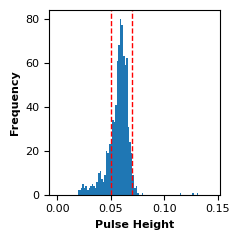

In [35]:
AlphaPlots(PulseHeights, RiseTimes, Time_us, "Test", 100, 100)

In [ ]:
"""
To upload to github, put into terminal:

git add .
git commit -m "update"
git push

"""